In [1]:
import anndata as ad
import umap
from anndata import AnnData
import os
import dynamo as dyn
import numpy as np
import matplotlib.pyplot as plt
import math
import scanpy as sc
import pickle
import seaborn as sns
import pandas as pd

/net/capricorn/home/xing/soh29/.conda/envs/latest_dynamo/lib/python3.10/site-packages/dynamo/get_version.py:180: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/net/capricorn/home/xing/soh29/.conda/envs/latest_dynamo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/net/capricorn/home/xing/soh29/.conda/envs/latest_dynamo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/net/capricorn/home/xing/soh29/.conda/envs/latest_dynamo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importi

In [2]:
import graphvelo
import scvelo as scv
import cellrank as cr

from graphvelo.utils import mack_score, adj_to_knn
from graphvelo.graph_velocity import GraphVelo
from graphvelo.plot import gene_score_histogram
from graphvelo.tangent_space import (_estimate_dt,
                                     binary_corr,
                                     inner_product,
                                     pearson_corr,
                                     cos_corr,
                                     corr_kernel,
                                     projection_with_transition_matrix,
                                     density_corrected_transition_matrix,
                                     _estimate_sigma)

In [3]:
data_path = '../03_velo/'

In [4]:
days_subset = ['0','5','7','10']

In [5]:
custom_colors = {
    '0': '#002a80',
    '5': '#8399e9',
    '7': '#f83c7b',
    '10': '#8e0014',
}

# Load genes

In [ ]:
file = open("gene_lists/macrophage_genes.txt")
macrophage_genes = file.readlines()
file.close()

In [ ]:
macrophage_genes = [gene.strip() for gene in macrophage_genes]

In [ ]:
file = open("gene_lists/dendritic_genes.txt")
dendritic_genes = file.readlines()
file.close()

In [ ]:
dendritic_genes = [gene.strip() for gene in dendritic_genes]

In [ ]:
valid_macro_dend = []
for gene in macrophage_genes + dendritic_genes:
    temp_gene = gene[0] + gene[1:].lower()
    if temp_gene in leiden_adata.var.index:
        valid_macro_dend.append(temp_gene)

In [ ]:
valid_macro = []
for gene in macrophage_genes:
    temp_gene = gene[0] + gene[1:].lower()
    if temp_gene in leiden_adata.var.index:
        valid_macro.append(temp_gene)

In [ ]:
valid_dend = []
for gene in dendritic_genes:
    temp_gene = gene[0] + gene[1:].lower()
    if temp_gene in leiden_adata.var.index:
        valid_dend.append(temp_gene)

# Functions

In [12]:
def save_processed_adata2(adata, file_name):
    temp_name = file_name + ".h5ad"
    file = open(file_name + '.pkl', 'wb')
    temp_dict = {}
    for key in adata.uns.keys():
        if 'neighbors' not in key:
            temp_dict[key] = adata.uns[key]
        
    pickle.dump(temp_dict, file)
    file.close()
    temp_adata = adata.copy()
    temp_adata.uns = {}
    temp_adata.write_h5ad(filename=temp_name)

In [13]:
def reload_processed_data(file_name):
    temp_name = file_name + ".h5ad"
    temp = dyn.read_h5ad(temp_name)
    loaded_dict = pd.read_pickle(file_name + '.pkl')
    temp.uns = loaded_dict
    return temp

In [14]:
import anndata
from scipy.sparse import csr_matrix
from dynamo.tools.utils import (
    index_condensed_matrix,
    linear_least_squares,
    nearest_neighbors,
    starmap_with_kwargs,
    timeit,
    update_dict,
    update_n_merge_dict,
)
from dynamo.vectorfield.utils import (
    FixedPoints,
    Hessian_rkhs_gaussian,
    Jacobian_kovf,
    Jacobian_numerical,
    Jacobian_rkhs_gaussian,
    Jacobian_rkhs_gaussian_parallel,
    Laplacian,
    NormDict,
    VecFldDict,
    compute_acceleration,
    compute_curl,
    compute_curvature,
    compute_divergence,
    compute_sensitivity,
    compute_torsion,
    con_K,
    con_K_div_cur_free,
    find_fixed_points,
    remove_redundant_points,
    vecfld_from_adata,
    vector_field_function,
    vector_transformation,
)

from scipy.stats import ttest_ind, mannwhitneyu

In [15]:
from dynamo.vectorfield.utils import get_jacobian
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import CubicSpline
from scipy.integrate import quad 
import pandas as pd

# Load data

In [18]:
temp = "generated_data/unprocessed_subset_data_06_2025/"
files = os.listdir(temp)

In [19]:
files[0] = files[4]
files = files[:4]

In [20]:
files

['new_control.h5ad', 'day5.h5ad', 'day7.h5ad', 'day10.h5ad']

In [21]:
adata_list = []
for file in files:
    temp_adata = dyn.read_h5ad(temp + file)
    adata_list.append(temp_adata)

In [22]:
adata_endo_list = []
for i in range(4):
    temp_adata = adata_list[i][adata_list[i].obs['Cell type'] == 'Endo']
    adata_endo_list.append(temp_adata)

In [23]:
new_rep_df = pd.read_csv("generated_data/new_rep_df.csv", index_col=0)

In [24]:
for i in range(4):
    temp = np.intersect1d(new_rep_df.index, adata_endo_list[i].obs.index)
    adata_endo_list[i] = adata_endo_list[i][temp,:]
    adata_endo_list[i].obsm['X_new3d'] = np.array(new_rep_df.loc[temp])
    adata_endo_list[i].obsm['X_new2d'] = np.array(new_rep_df.loc[temp])[:,:2]

/tmp/ipykernel_4099029/1517104057.py:4: ImplicitModificationWarning: Setting element `.obsm['X_new3d']` of view, initializing view as actual.
  adata_endo_list[i].obsm['X_new3d'] = np.array(new_rep_df.loc[temp])
/tmp/ipykernel_4099029/1517104057.py:4: ImplicitModificationWarning: Setting element `.obsm['X_new3d']` of view, initializing view as actual.
  adata_endo_list[i].obsm['X_new3d'] = np.array(new_rep_df.loc[temp])
/tmp/ipykernel_4099029/1517104057.py:4: ImplicitModificationWarning: Setting element `.obsm['X_new3d']` of view, initializing view as actual.
  adata_endo_list[i].obsm['X_new3d'] = np.array(new_rep_df.loc[temp])
/tmp/ipykernel_4099029/1517104057.py:4: ImplicitModificationWarning: Setting element `.obsm['X_new3d']` of view, initializing view as actual.
  adata_endo_list[i].obsm['X_new3d'] = np.array(new_rep_df.loc[temp])


In [25]:
combined_adata = ad.concat([adata_endo_list[0], 
                            adata_endo_list[1], 
                            adata_endo_list[2], 
                            adata_endo_list[3]])

In [26]:
leiden_adata = dyn.read_h5ad("generated_data/adata_subset_clusters.h5ad")

In [27]:
leiden_adata

AnnData object with n_obs × n_vars = 60535 × 33696
    obs: 'Day', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'leiden', 'Cell type'
    var: 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'score', 'log_cv', 'frac', 'use_for_pca', 'ntr'
    uns: 'Cell type_colors', 'Day_colors', 'PCs', 'dendrogram_leiden', 'explained_variance_ratio_', 'feature_selection', 'leiden', 'leiden_colors', 'neighbors', 'pca_fit', 'pca_mean', 'pp', 'rank_genes_groups', 'velocyto_SVR'
    obsm: 'X', 'X_pca', 'X_umap_combined'
    layers: 'X_spliced', 'X_unspliced', 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

# Identify Dendritic cells

|-----------> plotting with basis key=X_umap_combined
|-----------> skip filtering leiden by stack threshold when stacking color because it is not a numeric type


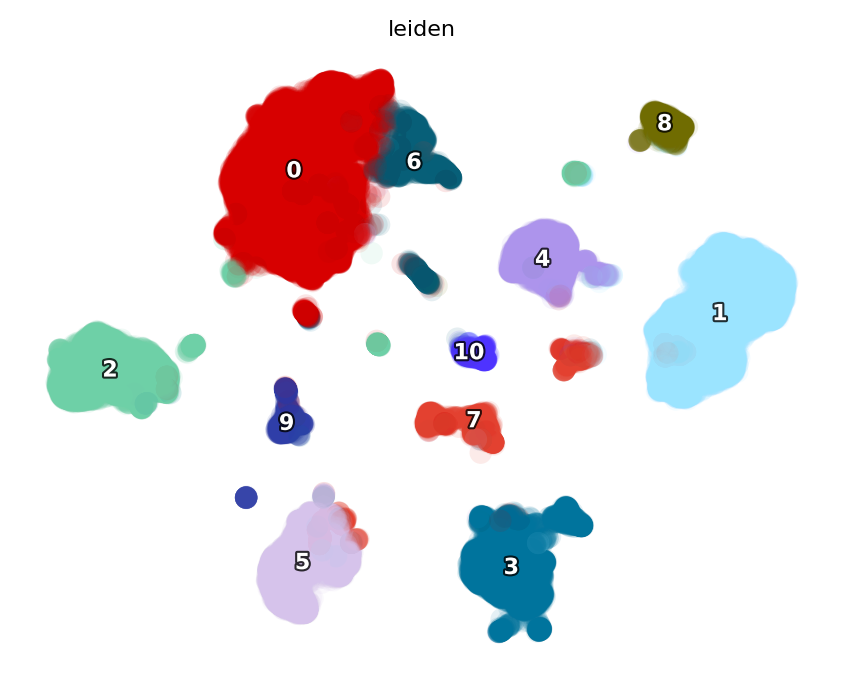

In [28]:
dyn.pl.scatters(leiden_adata, basis='umap_combined', color='leiden',
                #save_show_or_return='both', 
                #save_kwargs={'path': 'plots/leiden_clustering/', 'prefix': 'leiden', "dpi": 300, "ext": 'png', 'transparent': True} 
               )

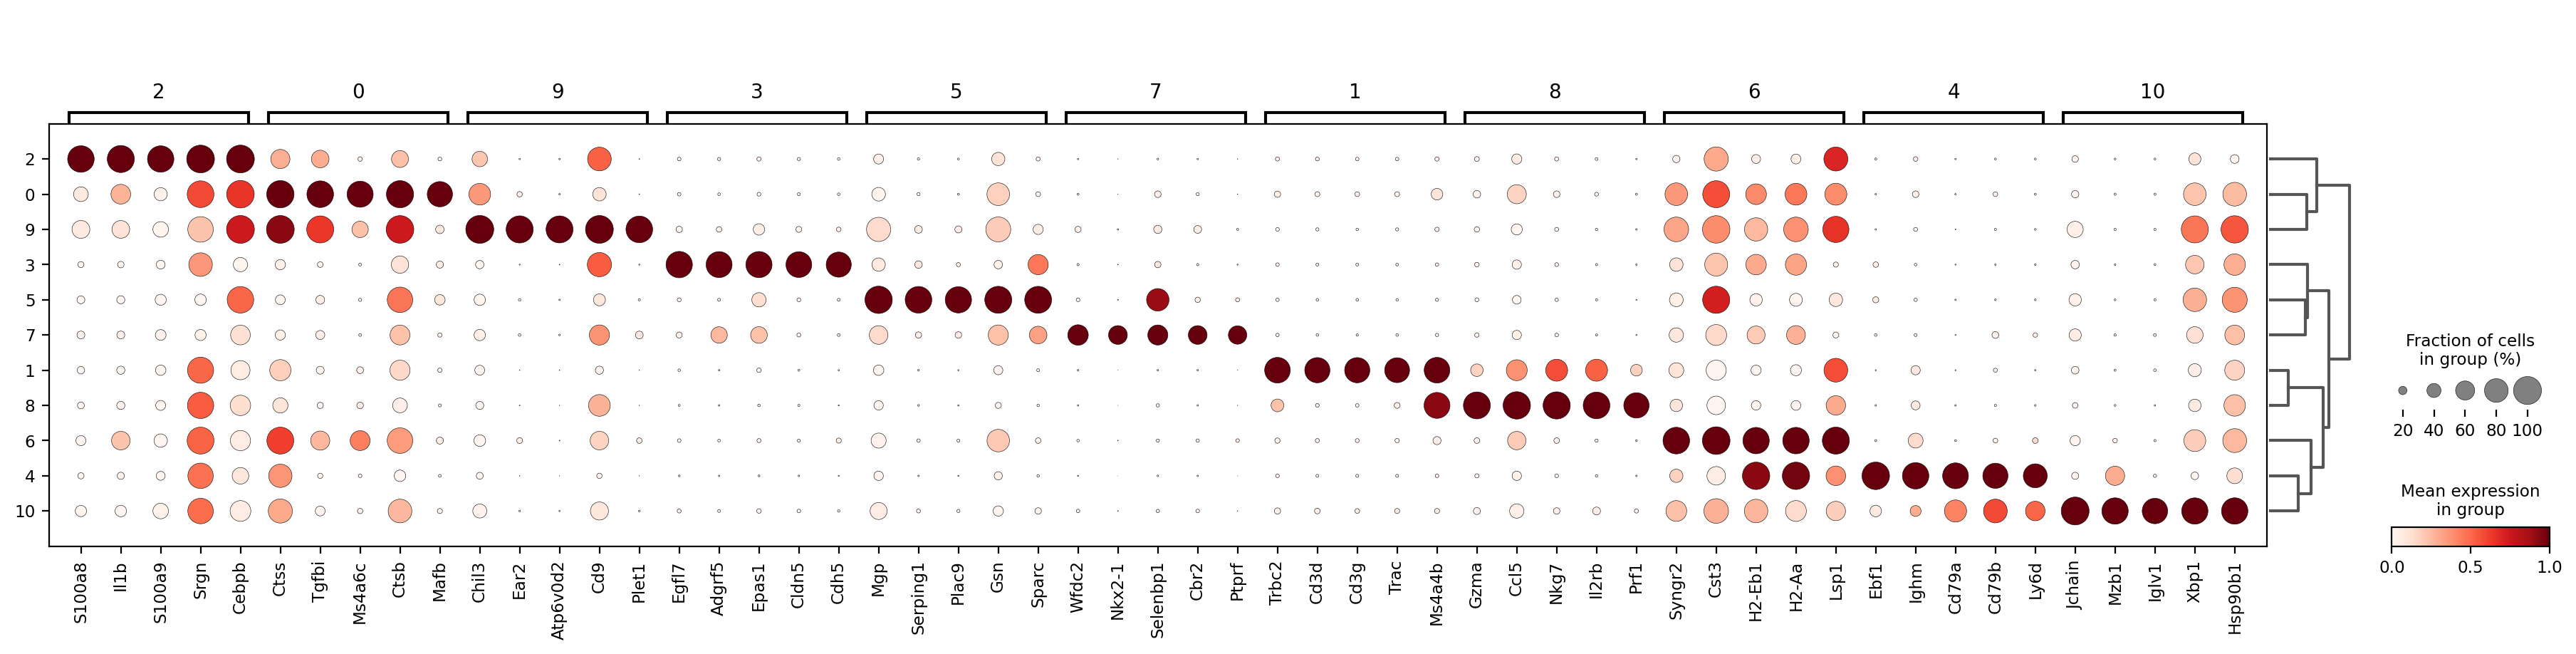

In [29]:
sc.pl.rank_genes_groups_dotplot(
    leiden_adata, groupby="leiden", standard_scale="var", n_genes=5, #save=True
)

In [30]:
temp = leiden_adata.uns['rank_genes_groups']['names']
as_2d_array = pd.DataFrame(np.stack([temp[name] for name in temp.dtype.names], axis=1), columns=temp.dtype.names)

In [31]:
genes = []
#for col in as_2d_array.columns:
for col in ['0','1','2','3']:
    temp = as_2d_array[col][:5]
    for gene in temp:
        genes.append(gene)

In [32]:
import matplotlib.colors as mcolors
cmap = plt.get_cmap("tab20", len(clusters))
clusters = leiden_adata.obs['leiden'].unique().tolist()
hex_colors = [mcolors.to_hex(cmap(i)) for i in range(len(clusters))]
lut = dict(zip(clusters, hex_colors))
col_colors = leiden_adata.obs['leiden'].map(lut)
X_data = pd.DataFrame(leiden_adata[:,genes].X.toarray(), columns=genes)
sns.clustermap(X_data, col_cluster=False, cmap='RdBu_r', yticklabels=1, col_colors=col_colors)
plt.show()

NameError: name 'clusters' is not defined

In [49]:
import matplotlib.colors as mcolors
cmap = plt.get_cmap("tab20", len(clusters))
clusters = leiden_adata.obs['leiden'].unique().tolist()
hex_colors = [mcolors.to_hex(cmap(i)) for i in range(len(clusters))]
lut = dict(zip(clusters, hex_colors))
col_colors = leiden_adata.obs['leiden'].map(lut)
X_data = pd.DataFrame(leiden_adata[:,genes].X.toarray(), columns=genes)
sns.clustermap(X_data, 
               col_cluster=False, 
               row_cluster=False,
               cmap='RdBu_r', xticklabels=1, col_colors=col_colors)
plt.show()

KeyboardInterrupt: 

In [32]:
genes = ['Pecam1','Cdh5',
         'Cd8a', 'Cd3e', 'Cd3g',
         'Cd68', 'Itgam', 'Ccr2', 'Arg1', 
         'Cd209a',
         'Itgax', 'Cd8a', 'Cd68', 'Cd80', 'Xcr1', 'Clec9a', 'Ly75', 'Itgae']

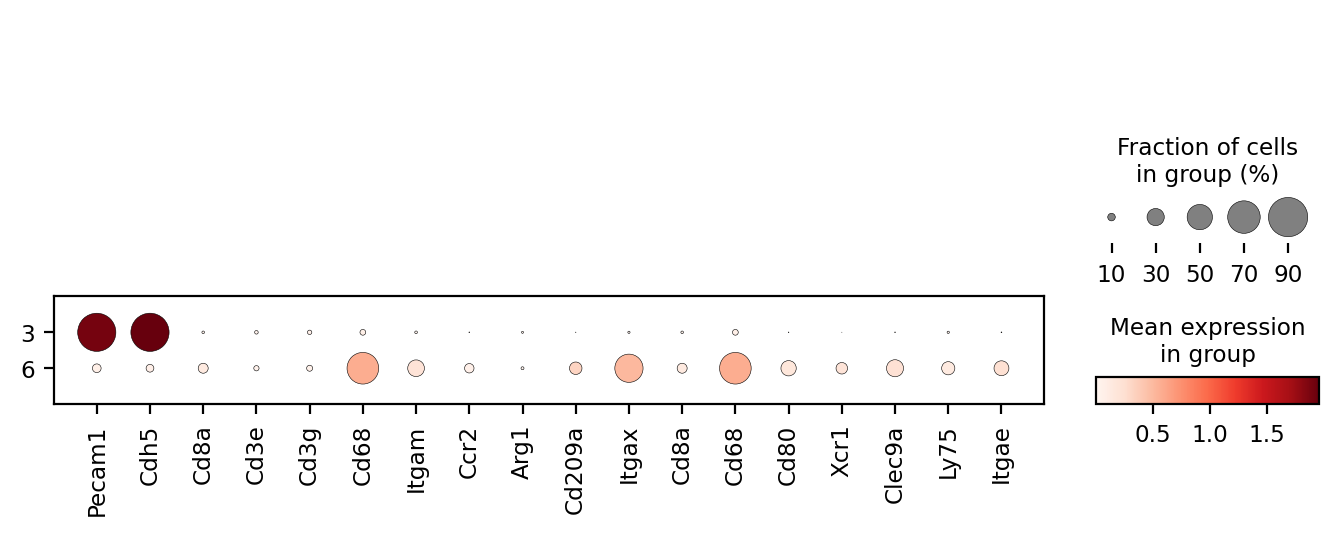

In [214]:
sc.pl.dotplot(leiden_adata_subset, genes, "leiden", dendrogram=True)

|-----------> plotting with basis key=X_umap_combined
Saving figure to plots/leiden_clustering/cd40_umap_dyn_savefig.png...
Done


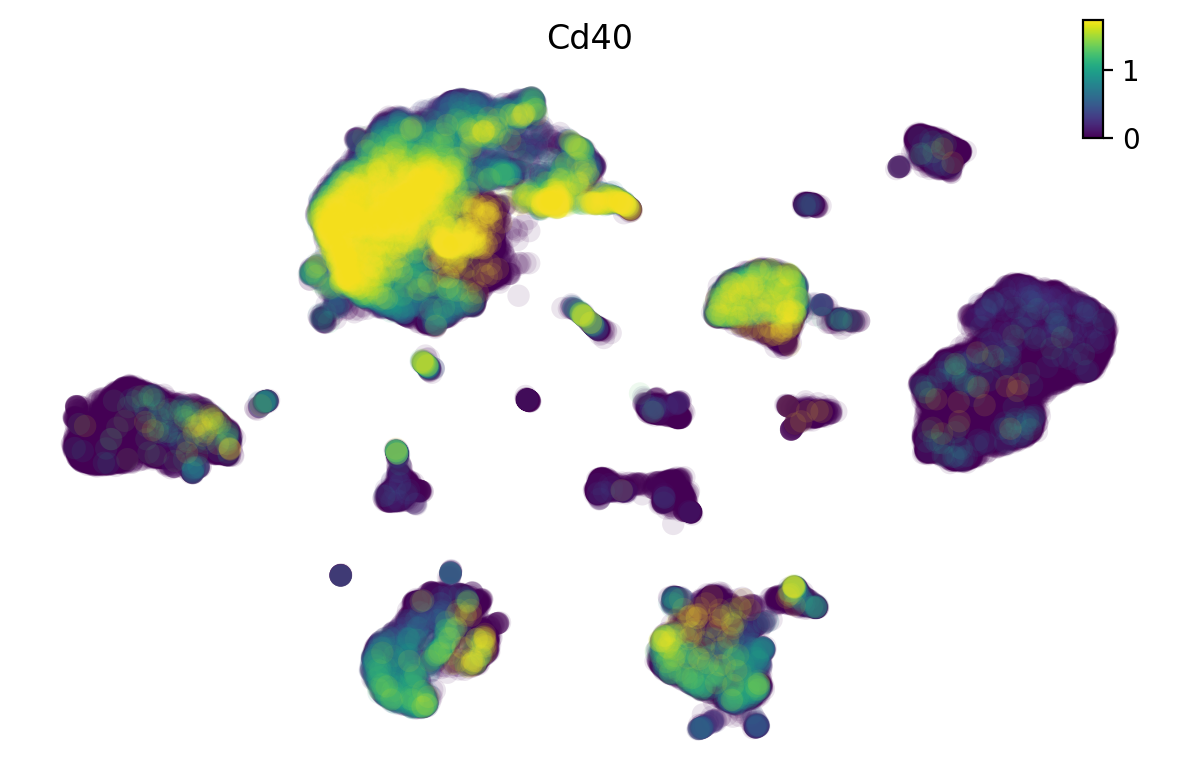

In [226]:
dyn.pl.scatters(leiden_adata, basis='umap_combined', color=['Cd40'],
                save_show_or_return='both', 
                #save_kwargs={'path': 'plots/leiden_clustering/', 'prefix': 'cd40_umap', "dpi": 300, "ext": 'png', 'transparent': True} 
)

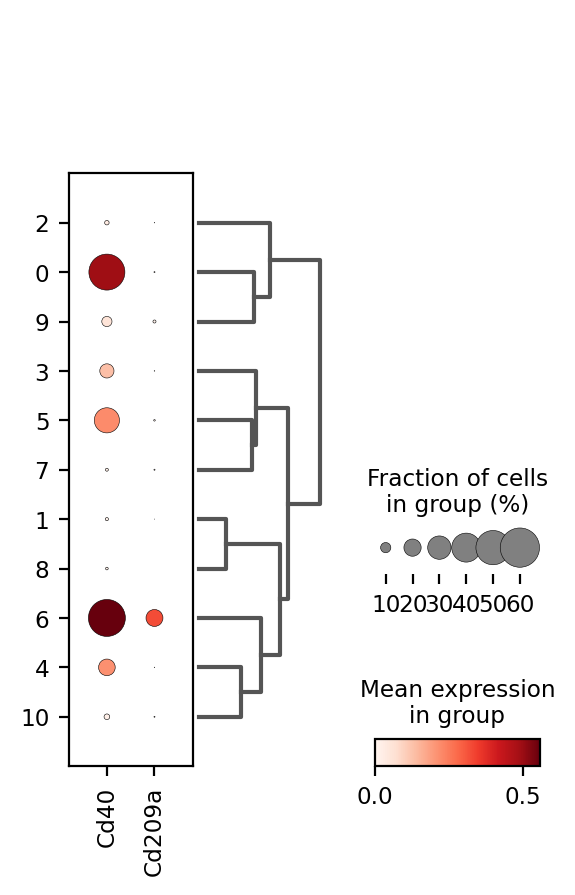

In [225]:
sc.pl.dotplot(leiden_adata, ['Cd40','Cd209a'], "leiden", dendrogram=True,
              #save="Cd40_dotplot.png"
             )

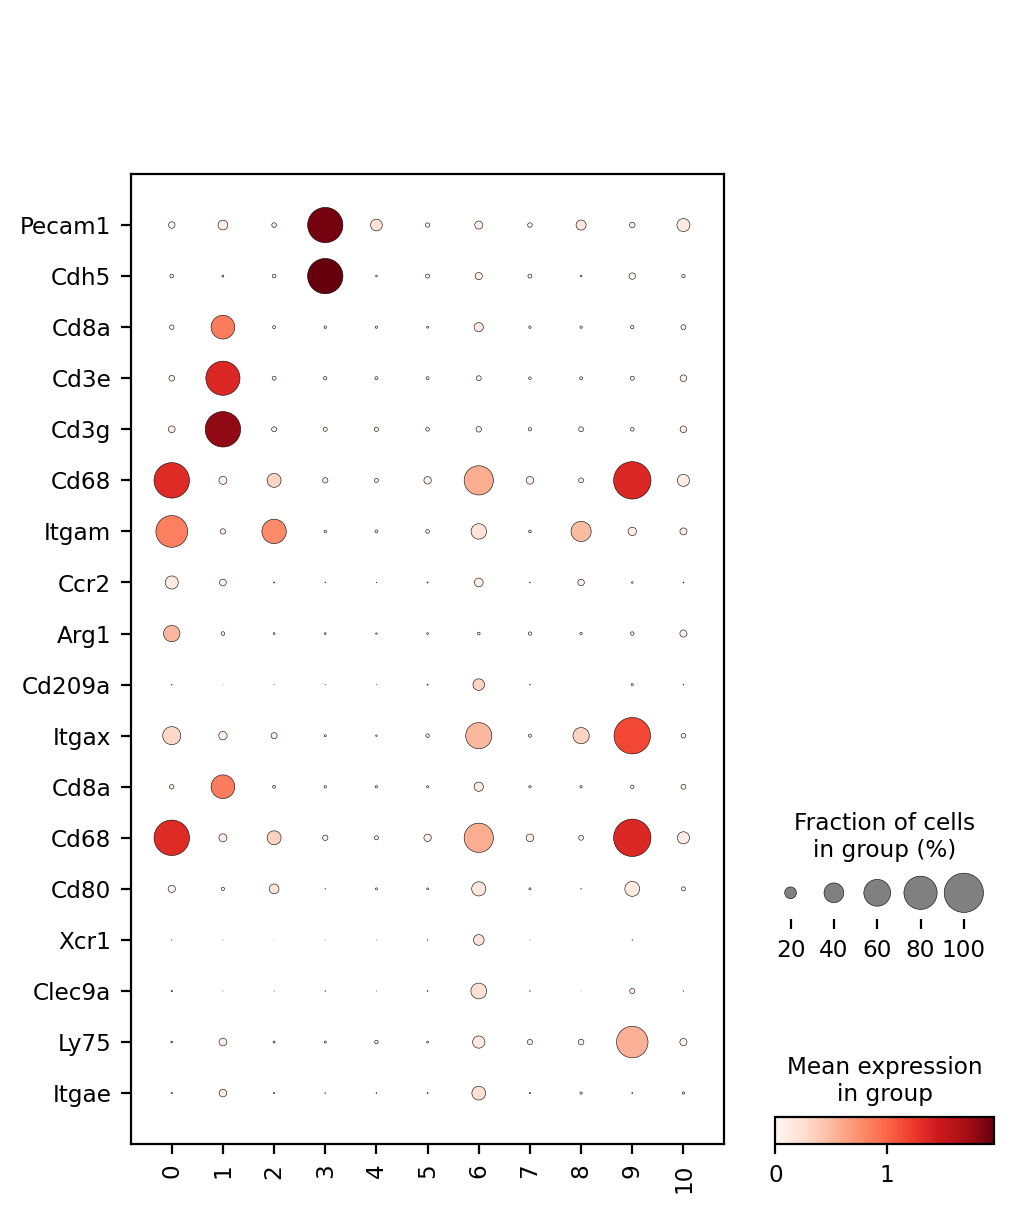

In [34]:
sc.pl.dotplot(leiden_adata, genes, "leiden", dendrogram=False, swap_axes=True,
              #save="cell_type_dotplot.png"
             )
plt.show()

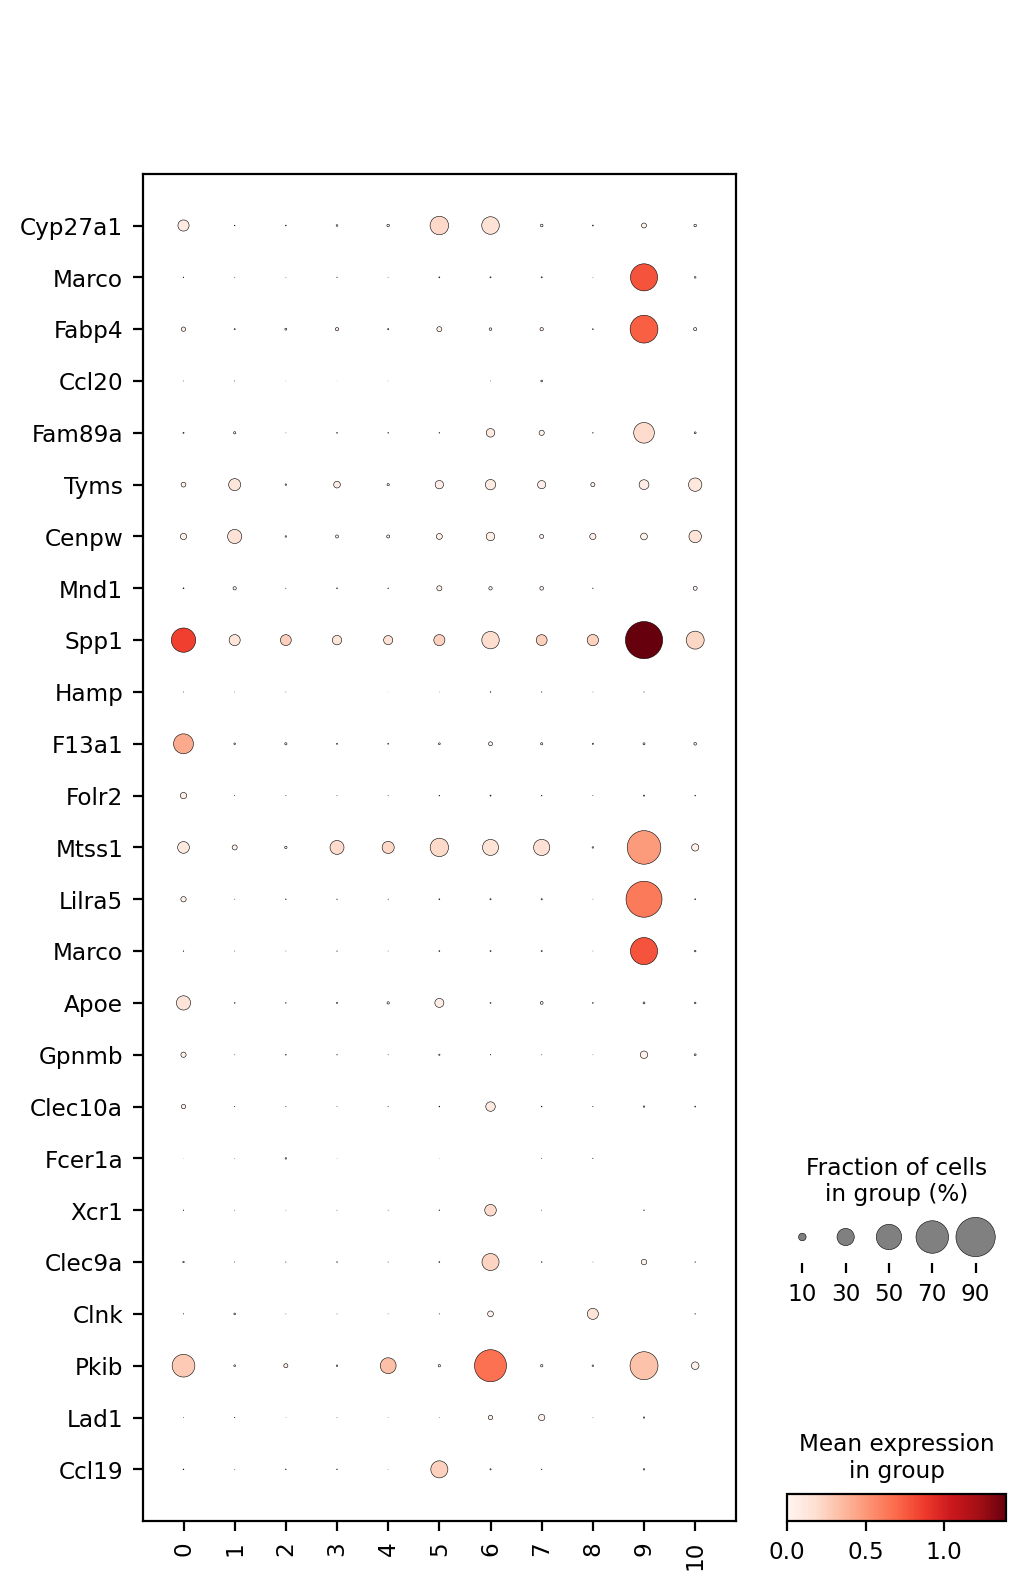

In [58]:
sc.pl.dotplot(leiden_adata, valid_macro_dend, "leiden", dendrogram=False, swap_axes=True,
              save="macrophage_dc_genes.png"
             )
plt.show()

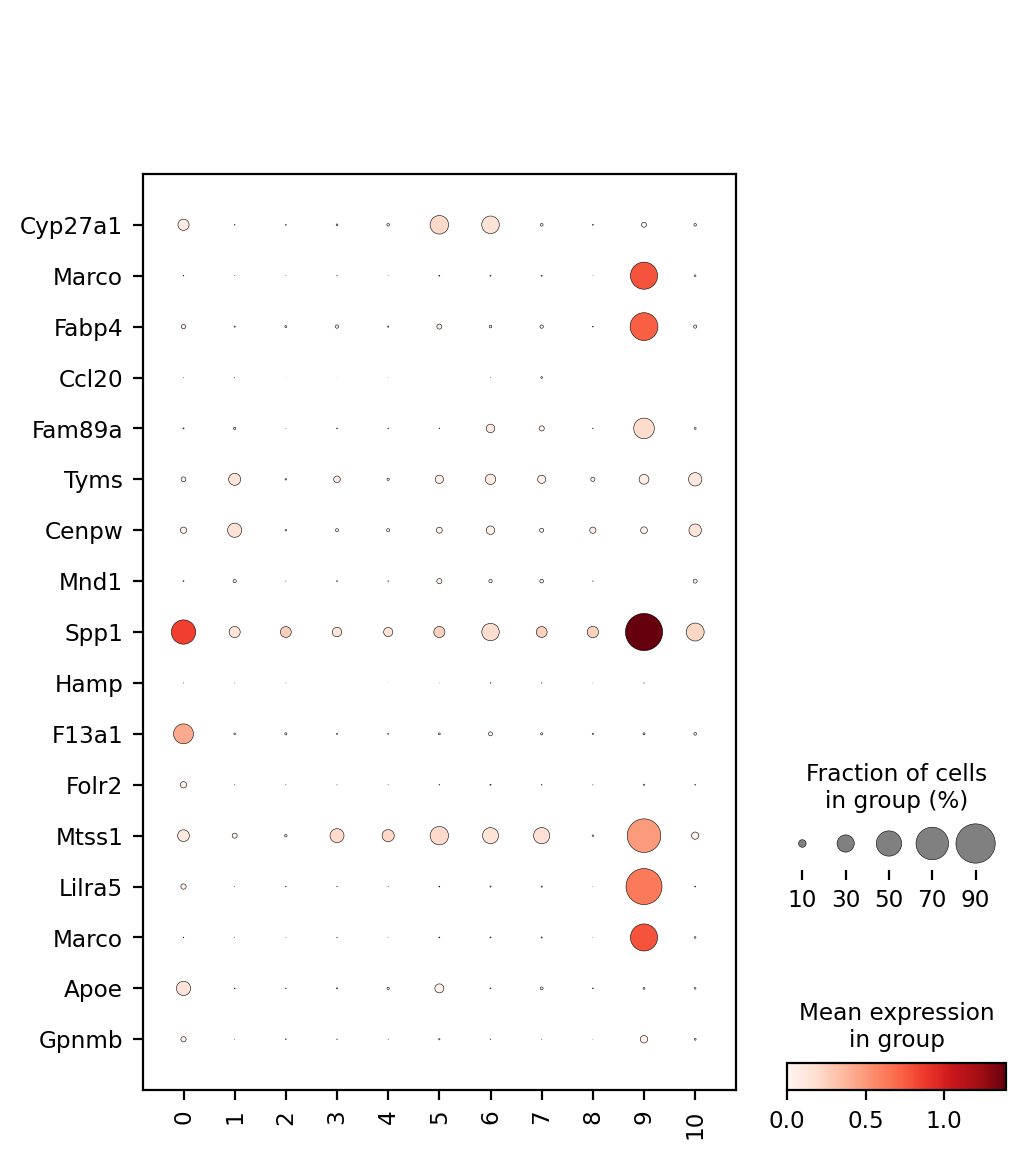

In [55]:
sc.pl.dotplot(leiden_adata, valid_macro, "leiden", dendrogram=False, swap_axes=True,
              save="macrophage_genes.png"
             )
plt.show()

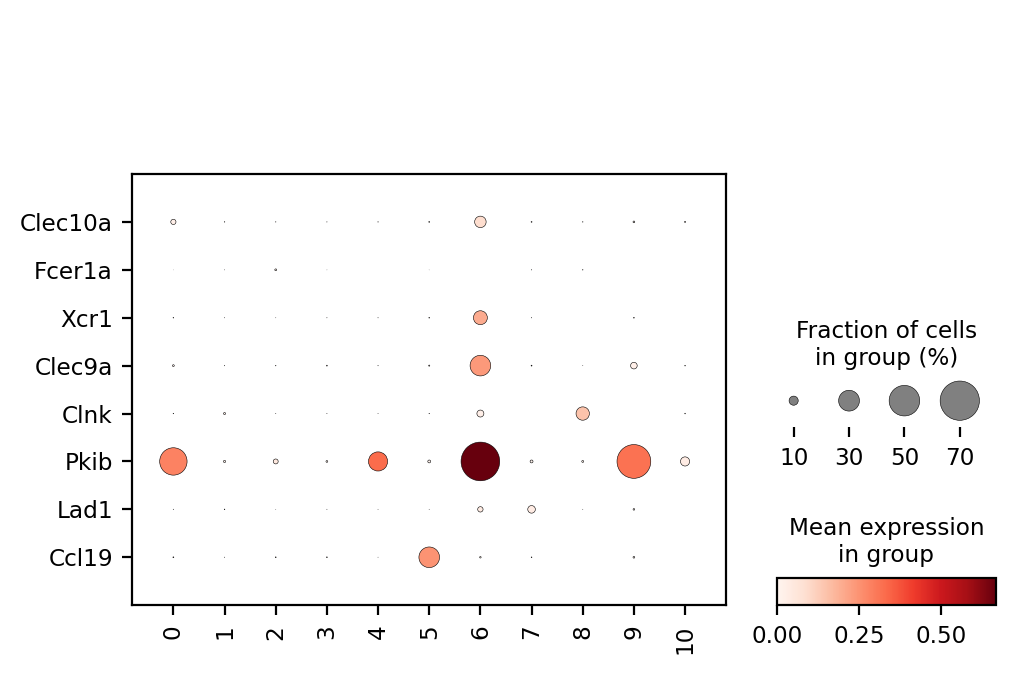

In [57]:
sc.pl.dotplot(leiden_adata, valid_dend, "leiden", dendrogram=False, swap_axes=True,
              save="dc_genes.png"
             )
plt.show()

In [59]:
macro_den_adata = leiden_adata[(leiden_adata.obs['leiden'] == "9") |
                               (leiden_adata.obs['leiden'] == "0") |
                               (leiden_adata.obs['leiden'] == "6")]

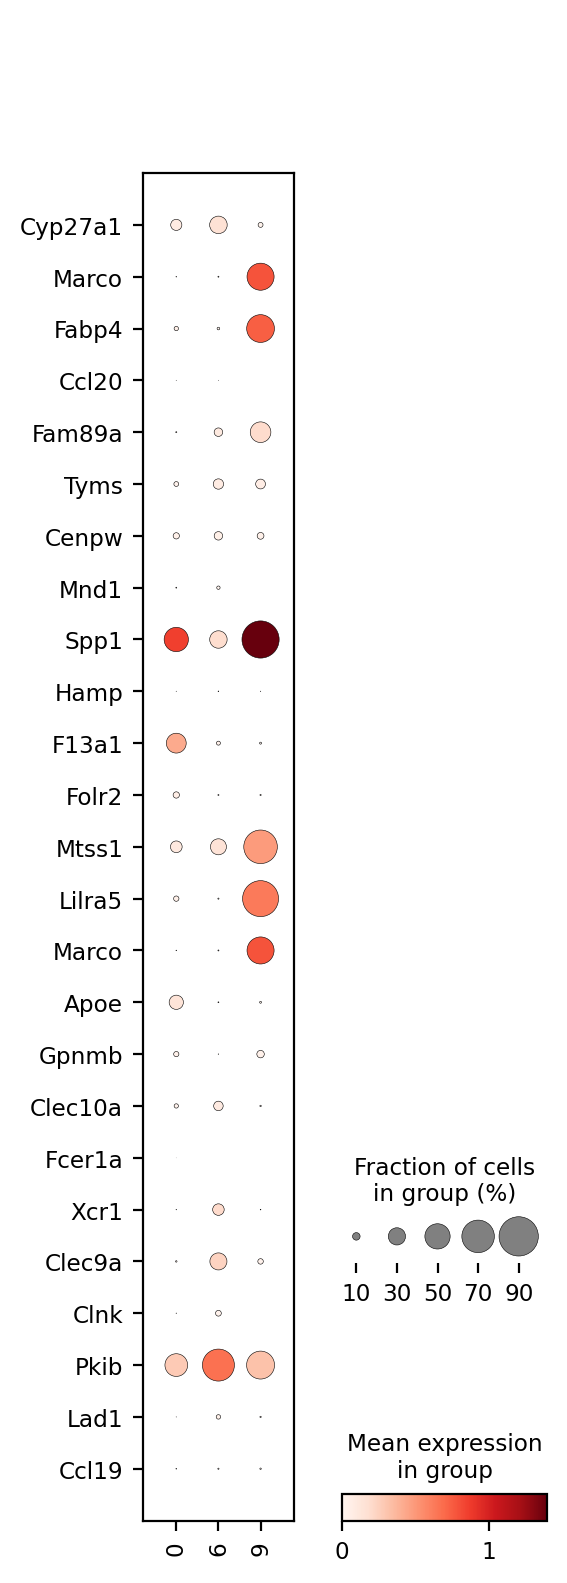

In [61]:
sc.pl.dotplot(macro_den_adata, valid_macro_dend, "leiden", dendrogram=False, swap_axes=True,
              save="macrophage_dc_genes_subset.png"
             )
plt.show()

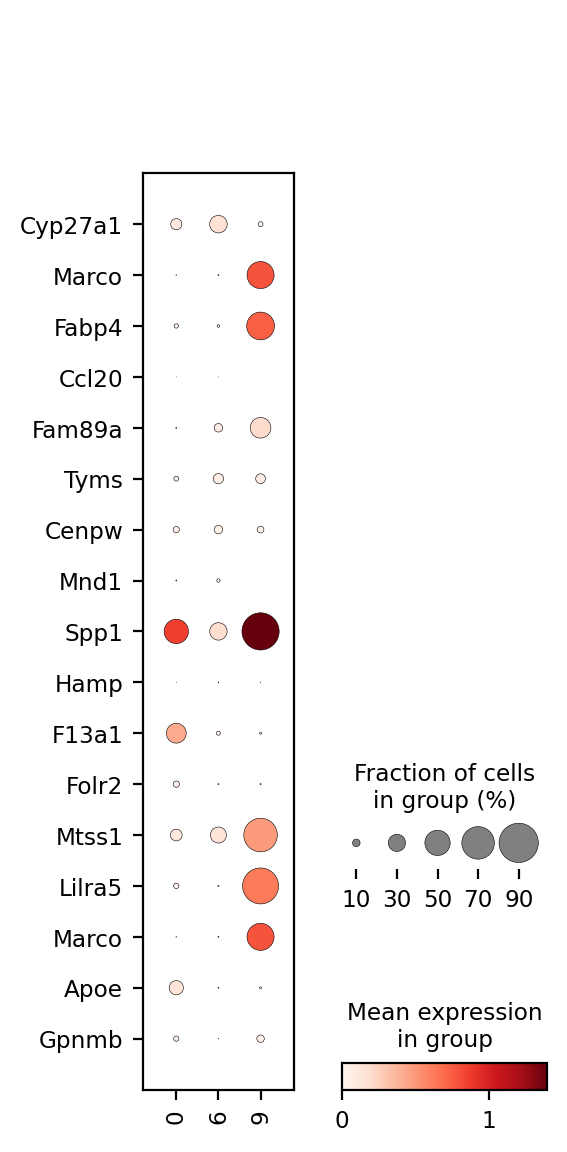

In [62]:
sc.pl.dotplot(macro_den_adata, valid_macro, "leiden", dendrogram=False, swap_axes=True,
              save="macrophage_genes_subset.png"
             )
plt.show()

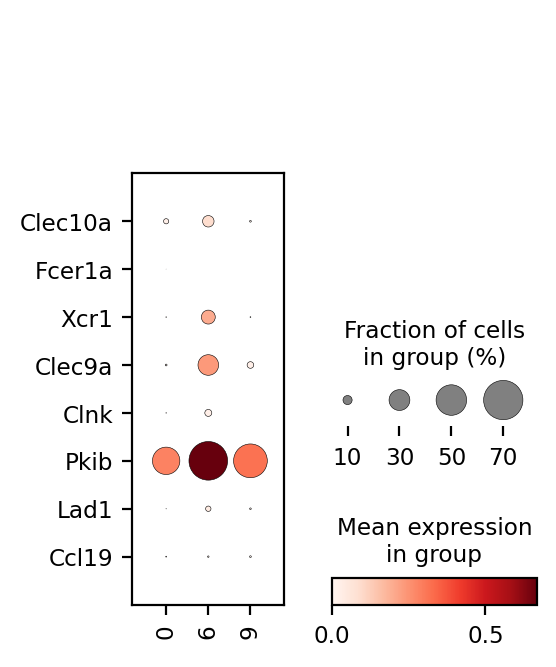

In [63]:
sc.pl.dotplot(macro_den_adata, valid_dend, "leiden", dendrogram=False, swap_axes=True,
              save="dc_genes_subset.png"
             )
plt.show()